# Notebook 0 — Data Cleaning
## VCCR / Forensz DataLab IV

Dit notebook laadt de ruwe data uit **één bronbestand** (`Anoniem1 - NS Transacties 2024 - uitbreiding.xlsx`),
voert alle noodzakelijke opschoonstappen uit, en slaat de resultaten op als CSV-bestanden in `data/clean/`.

**Groepen:**
- **A** — Werkgever A (grootste groep)
- **B** — Werkgever B
- **C** — Werkgever C (uitbreidingsgroep met extra kolommen)


## 0. Imports en configuratie

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_DIR  = '../data/'
CLEAN_DIR = '../data/clean/'
FILE_UIT  = DATA_DIR + 'Anoniem1 - NS Transacties 2024 - uitbreiding.xlsx'

Path(CLEAN_DIR).mkdir(parents=True, exist_ok=True)
print('Configuratie klaar. Clean-map:', CLEAN_DIR)

Configuratie klaar. Clean-map: ../data/clean/


## 1. Inladen ruwe data

We laden alle relevante sheets uit het uitbreidingsbestand.

In [51]:
# Business Cards
bc_a = pd.read_excel(FILE_UIT, sheet_name='NS-Business Cards (A)')
bc_b = pd.read_excel(FILE_UIT, sheet_name='NS-Business Cards (B)')
bc_c = pd.read_excel(FILE_UIT, sheet_name='NS-Business Cards (C)')

# Transacties
tx_a = pd.read_excel(FILE_UIT, sheet_name='Transacties (A)')
tx_b = pd.read_excel(FILE_UIT, sheet_name='Transacties (B)')
tx_c = pd.read_excel(FILE_UIT, sheet_name='Transacties (C)')

# Referentietabellen
ref_motieven    = pd.read_excel(FILE_UIT, sheet_name='Motieven')
ref_categorieen = pd.read_excel(FILE_UIT, sheet_name='Categoriën')
ref_abonnementen= pd.read_excel(FILE_UIT, sheet_name='Abonnementen')
ref_producten   = pd.read_excel(FILE_UIT, sheet_name='Producten')
ref_statussen   = pd.read_excel(FILE_UIT, sheet_name='Statussen')

# Overzicht shapes
overzicht = {
    'BC A': bc_a.shape, 'BC B': bc_b.shape, 'BC C': bc_c.shape,
    'TX A': tx_a.shape, 'TX B': tx_b.shape, 'TX C': tx_c.shape,
    'Motieven': ref_motieven.shape, 'Categoriën': ref_categorieen.shape,
    'Abonnementen': ref_abonnementen.shape, 'Producten': ref_producten.shape,
    'Statussen': ref_statussen.shape,
}
for naam, shape in overzicht.items():
    print(f'{naam:15s}: {shape[0]:>7,} rijen × {shape[1]:>3} kolommen')

BC A           :   2,525 rijen ×  53 kolommen
BC B           :     754 rijen ×  53 kolommen
BC C           :     404 rijen ×  52 kolommen
TX A           : 145,572 rijen ×  41 kolommen
TX B           :  34,010 rijen ×  41 kolommen
TX C           :  22,852 rijen ×  43 kolommen
Motieven       :       9 rijen ×   2 kolommen
Categoriën     :       5 rijen ×   2 kolommen
Abonnementen   :       6 rijen ×   2 kolommen
Producten      :      11 rijen ×   3 kolommen
Statussen      :       8 rijen ×   2 kolommen


## 2. Overzicht kolomnamen en datatypes

In [52]:
print('=== BC A kolommen ==='); print(list(bc_a.columns))
print('\n=== BC C kolommen ==='); print(list(bc_c.columns))
print('\n--- Verschil BC A vs BC C ---')
print('Alleen in A:', set(bc_a.columns) - set(bc_c.columns))
print('Alleen in C:', set(bc_c.columns) - set(bc_a.columns))

print('\n=== TX A kolommen ==='); print(list(tx_a.columns))
print('\n--- Verschil TX A vs TX B ---')
print('Alleen in A:', set(tx_a.columns) - set(tx_b.columns))
print('Alleen in B:', set(tx_b.columns) - set(tx_a.columns))
print('\n--- Verschil TX A vs TX C ---')
print('Alleen in C:', set(tx_c.columns) - set(tx_a.columns))

=== BC A kolommen ===
['Afdelingsnummer', 'Afdelingsnaam', 'Begindatum', 'Achternaam', 'Voorletters', 'Tussenvoegsel', 'Straat', 'Huisnummer', 'Toevoeging', 'Postcode', 'Plaats', 'Land', 'Geslacht', 'Geboortedatum', 'Personeelsnummer', 'E-mail/gebruikersnaam', 'Telefoonnummer Zakelijk', 'Telefoonnummer Mobiel', 'Kostenplaats', 'Pasfoto nummer', 'Ingangsdatum pasfoto', 'Einddatum pasfoto', 'Contractnummer', 'AC Code', 'Gewenste beëindigingsdatum', 'Geregistreerde beëindigingsdatum', 'Kaartnummer', 'Vervangen door', 'Vervangingsreden', 'Vervaldatum kaart', 'Status', 'Klasse', 'Vertrekstation', 'Aankomst station', 'Tarief eenheden', 'Kaarthoudernummer', 'Boekingsnummer', 'Kenmerk 3', 'Abonnement', 'Nieuwe portfolio', 'Aanvullend trein-abonnement', 'Aanvullend OV-abonnement', 'Fiets parkeren', 'P+R parkeren', 'Parkeren op straat', 'Taxi', 'Internationaal reizen', 'BTM', 'Deelauto', 'Deelscooter', 'Deelfiets', 'Electrische deelfiets', 'Permissie deur-tot-deur dienst']

=== BC C kolommen ===

- - -
## 3. Datacleaning



### 3.1 Electrische deelfiets toevoegen aan groep C

BC C mist de kolom Electrische deelfiets. We voegen deze toe als NaN zodat concat werkt.

In [53]:
if 'Electrische deelfiets' not in bc_c.columns:
    bc_c['Electrische deelfiets'] = np.nan
    print('BC C: kolom Electrische deelfiets toegevoegd (NaN)')
else:
    print('BC C: kolom al aanwezig')

# Controleer alle BC's dezelfde kolommen hebben
cols_a, cols_b, cols_c = set(bc_a.columns), set(bc_b.columns), set(bc_c.columns)
print('\nNog ontbrekend in C:', cols_a - cols_c)
print('Nog ontbrekend in A:', cols_c - cols_a)

BC C: kolom Electrische deelfiets toegevoegd (NaN)

Nog ontbrekend in C: set()
Nog ontbrekend in A: set()


### 3.3 Personeelsnummer en Pers.nummer als string

Numerieke ID's moeten als string behandeld worden voor de merge.

In [54]:
def id_naar_string(serie):
    """Converteert ID-kolom naar string, behoudt NaN als NaN."""
    return serie.apply(
        lambda x: str(x).strip() if pd.notna(x) else np.nan
    )

for df, naam in [(bc_a,'BC A'), (bc_b,'BC B'), (bc_c,'BC C')]:
    df['Personeelsnummer'] = id_naar_string(df['Personeelsnummer'])

for df, naam in [(tx_a,'TX A'), (tx_b,'TX B'), (tx_c,'TX C')]:
    df['Pers.nummer'] = id_naar_string(df['Pers.nummer'])

print('Voorbeeld BC A Personeelsnummer:', bc_a['Personeelsnummer'].dropna().head(3).tolist())
print('Voorbeeld TX A Pers.nummer:', tx_a['Pers.nummer'].dropna().head(3).tolist())
print('Dtype BC A Personeelsnummer:', bc_a['Personeelsnummer'].dtype)

Voorbeeld BC A Personeelsnummer: ['5009281', '5009281', '126340']
Voorbeeld TX A Pers.nummer: ['110701.0', '110701.0', '110701.0']
Dtype BC A Personeelsnummer: object


### 3.4 Datum parsing

De kolom Datum in de transactiebestanden wordt naar datetime geconverteerd.

In [55]:
for df, naam in [(tx_a,'TX A'), (tx_b,'TX B'), (tx_c,'TX C')]:
    df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce')
    print(f'{naam}: Datum {df["Datum"].min().date()} → {df["Datum"].max().date()}, '
          f'NaN: {df["Datum"].isna().sum()}')

TX A: Datum 2023-08-01 → 2024-12-31, NaN: 12
TX B: Datum 2024-05-05 → 2025-01-14, NaN: 0
TX C: Datum 2023-08-02 → 2024-12-31, NaN: 0


### 3.5 Groeplabel toevoegen

In [56]:
for df, groep in [(bc_a,'A'),(bc_b,'B'),(bc_c,'C'),
                  (tx_a,'A'),(tx_b,'B'),(tx_c,'C')]:
    df['groep'] = groep
print('Groeplabels toegevoegd.')

Groeplabels toegevoegd.


## 4. Duplicaten controle

In [57]:
print('=== Duplicaten in Business Cards (op Personeelsnummer + Kaartnummer) ===')
for df, naam in [(bc_a,'BC A'),(bc_b,'BC B'),(bc_c,'BC C')]:
    dup_keys = ['Personeelsnummer','Kaartnummer'] if 'Kaartnummer' in df.columns else ['Personeelsnummer']
    n_dup = df.duplicated(subset=dup_keys).sum()
    print(f'{naam}: {n_dup} duplicaten ({n_dup/len(df)*100:.2f}%)')

print('\n=== Duplicaten in Transacties (op Transactienummer) ===')
for df, naam in [(tx_a,'TX A'),(tx_b,'TX B'),(tx_c,'TX C')]:
    if 'Transactienummer' in df.columns:
        n_dup = df.duplicated(subset=['Transactienummer']).sum()
        print(f'{naam}: {n_dup} duplicaten ({n_dup/len(df)*100:.2f}%)')
    else:
        n_dup = df.duplicated().sum()
        print(f'{naam}: {n_dup} volledige duplicaten')

=== Duplicaten in Business Cards (op Personeelsnummer + Kaartnummer) ===
BC A: 103 duplicaten (4.08%)
BC B: 0 duplicaten (0.00%)
BC C: 9 duplicaten (2.23%)

=== Duplicaten in Transacties (op Transactienummer) ===
TX A: 99 duplicaten (0.07%)
TX B: 59 duplicaten (0.17%)
TX C: 2 duplicaten (0.01%)


## 5. Missende waarden analyse

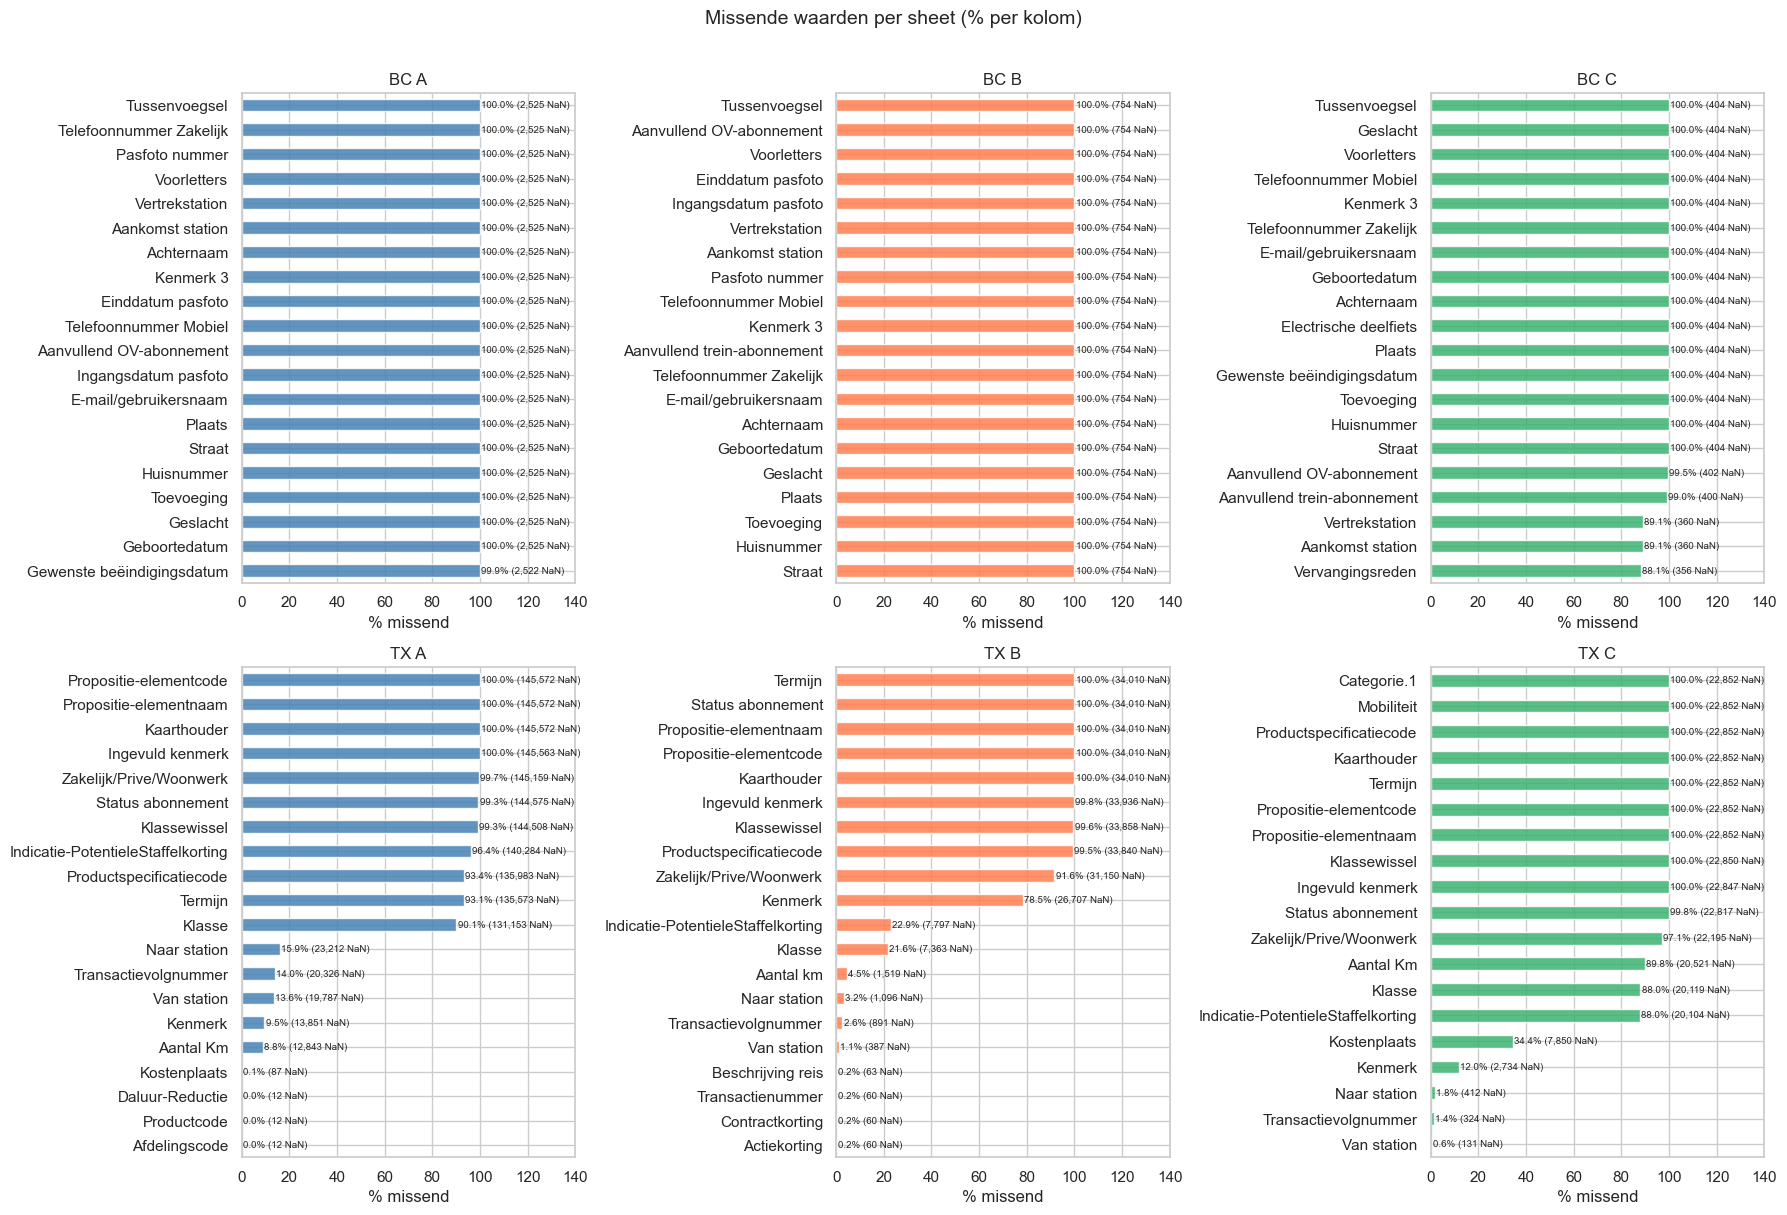

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Missende waarden per sheet (% per kolom)', fontsize=14, y=1.01)

datasets = [
    (bc_a, 'BC A', 'steelblue'),
    (bc_b, 'BC B', 'coral'),
    (bc_c, 'BC C', 'mediumseagreen'),
    (tx_a, 'TX A', 'steelblue'),
    (tx_b, 'TX B', 'coral'),
    (tx_c, 'TX C', 'mediumseagreen'),
]

for ax, (df, naam, kleur) in zip(axes.flatten(), datasets):
    mis_pct = df.isna().mean().mul(100).sort_values(ascending=True)
    mis_count = df.isna().sum().reindex(mis_pct.index)
    
    # Toon ALLE kolommen met missende waarden (niet alleen >0)
    mask = mis_pct >= 0  # alles tonen
    mis_pct = mis_pct[mis_pct > 0].tail(20)  # top 20
    mis_count = mis_count.reindex(mis_pct.index)
    
    if len(mis_pct) == 0:
        ax.text(0.5, 0.5, 'Geen missende waarden', ha='center', va='center', transform=ax.transAxes)
    else:
        mis_pct.plot(kind='barh', ax=ax, color=kleur, alpha=0.85)
        for i, (pct, count) in enumerate(zip(mis_pct, mis_count)):
            ax.text(pct + 0.5, i, f'{pct:.1f}% ({int(count):,} NaN)', va='center', fontsize=7)
    ax.set_title(naam)
    ax.set_xlabel('% missend')
    ax.set_xlim(0, 140)

plt.tight_layout()
plt.show()

 - - -
 ### 100% lege kolommen verwijderen

In [60]:
# Business Cards
print('--- Business Cards ---')
for naam, df in [('BC A', bc_a), ('BC B', bc_b), ('BC C', bc_c)]:
    lege_kolommen = df.columns[df.isnull().all()].tolist()
    df.drop(columns=lege_kolommen, inplace=True)
    print(f'{naam}: {len(lege_kolommen)} kolommen verwijderd → {df.shape[1]} kolommen over')
    if lege_kolommen:
        print(f'  Verwijderd: {lege_kolommen}')

# Transacties
print('\n--- Transacties ---')
for naam, df in [('TX A', tx_a), ('TX B', tx_b), ('TX C', tx_c)]:
    lege_kolommen = df.columns[df.isnull().all()].tolist()
    df.drop(columns=lege_kolommen, inplace=True)
    print(f'{naam}: {len(lege_kolommen)} kolommen verwijderd → {df.shape[1]} kolommen over')
    if lege_kolommen:
        # print(f'  Verwijderd: {lege_kolommen}')
        print('Verwijderd')


--- Business Cards ---
BC A: 19 kolommen verwijderd → 35 kolommen over
  Verwijderd: ['Achternaam', 'Voorletters', 'Tussenvoegsel', 'Straat', 'Huisnummer', 'Toevoeging', 'Plaats', 'Geslacht', 'Geboortedatum', 'E-mail/gebruikersnaam', 'Telefoonnummer Zakelijk', 'Telefoonnummer Mobiel', 'Pasfoto nummer', 'Ingangsdatum pasfoto', 'Einddatum pasfoto', 'Vertrekstation', 'Aankomst station', 'Kenmerk 3', 'Aanvullend OV-abonnement']
BC B: 21 kolommen verwijderd → 33 kolommen over
  Verwijderd: ['Achternaam', 'Voorletters', 'Tussenvoegsel', 'Straat', 'Huisnummer', 'Toevoeging', 'Plaats', 'Geslacht', 'Geboortedatum', 'E-mail/gebruikersnaam', 'Telefoonnummer Zakelijk', 'Telefoonnummer Mobiel', 'Pasfoto nummer', 'Ingangsdatum pasfoto', 'Einddatum pasfoto', 'Gewenste beëindigingsdatum', 'Vertrekstation', 'Aankomst station', 'Kenmerk 3', 'Aanvullend trein-abonnement', 'Aanvullend OV-abonnement']
BC C: 15 kolommen verwijderd → 39 kolommen over
  Verwijderd: ['Achternaam', 'Voorletters', 'Tussenvoegsel

### Niet-nuttige kolommen verwijderen 

In [61]:

print('=== Niet-nuttige kolommen verwijderen ===\n')

# BC: Tarief eenheden (altijd 0, niet informatief)
for naam, df in [('BC A', bc_a), ('BC B', bc_b), ('BC C', bc_c)]:
    df.drop(columns=['Tarief eenheden'], inplace=True, errors='ignore')
print('BC: "Tarief eenheden" verwijderd (altijd 0)')

# TX: Kolommen die >90% leeg zijn en niet relevant voor de agent
tx_verwijder = [
    'Ingevuld kenmerk',
    'Zakelijk/Prive/Woonwerk',
    'Status abonnement',
    'Klassewissel',
    'Indicatie-PotentieleStaffelkorting',
    'Productspecificatiecode'
]

for naam, df in [('TX A', tx_a), ('TX B', tx_b), ('TX C', tx_c)]:
    bestaand = [c for c in tx_verwijder if c in df.columns]
    df.drop(columns=bestaand, inplace=True)
    print(f'{naam}: {len(bestaand)} kolommen verwijderd')

print(f'\n=== Resultaat ===')
for naam, df in [('BC A', bc_a), ('BC B', bc_b), ('BC C', bc_c),
                  ('TX A', tx_a), ('TX B', tx_b), ('TX C', tx_c)]:
    print(f'{naam}: {df.shape[1]} kolommen, {len(df):,} rijen')

=== Niet-nuttige kolommen verwijderen ===

BC: "Tarief eenheden" verwijderd (altijd 0)
TX A: 6 kolommen verwijderd
TX B: 5 kolommen verwijderd
TX C: 5 kolommen verwijderd

=== Resultaat ===
BC A: 34 kolommen, 2,525 rijen
BC B: 32 kolommen, 754 rijen
BC C: 38 kolommen, 404 rijen
TX A: 33 kolommen, 145,572 rijen
TX B: 32 kolommen, 34,010 rijen
TX C: 32 kolommen, 22,852 rijen


In [62]:
# ── Kolommen gelijktrekken ─────────────────────────────────────────────
print('=== Kolommen gelijktrekken ===\n')

# BC: Verwijder kolommen die bijna helemaal leeg zijn en niet nuttig
bc_a.drop(columns=['Gewenste beëindigingsdatum'], inplace=True, errors='ignore')
print('BC A: "Gewenste beëindigingsdatum" verwijderd (99.9% leeg)')

# TX: "Aantal km" (kleine k) samenvoegen met "Aantal Km" (hoofdletter)
if 'Aantal km' in tx_b.columns and 'Aantal Km' in tx_b.columns:
    tx_b['Aantal Km'] = tx_b['Aantal Km'].fillna(tx_b['Aantal km'])
    tx_b.drop(columns=['Aantal km'], inplace=True)
    print('TX B: "Aantal km" samengevoegd met "Aantal Km"')
elif 'Aantal km' in tx_b.columns:
    tx_b.rename(columns={'Aantal km': 'Aantal Km'}, inplace=True)
    print('TX B: "Aantal km" hernoemd naar "Aantal Km"')

# TX: Verwijder "Termijn" uit TX A (93% leeg)
tx_a.drop(columns=['Termijn'], inplace=True, errors='ignore')
print('TX A: "Termijn" verwijderd (93% leeg)')

# Check resultaat
print(f'\n=== Na gelijktrekken ===')
print(f'BC A: {bc_a.shape[1]} kolommen')
print(f'BC B: {bc_b.shape[1]} kolommen')
print(f'BC C: {bc_c.shape[1]} kolommen')
print(f'TX A: {tx_a.shape[1]} kolommen')
print(f'TX B: {tx_b.shape[1]} kolommen')
print(f'TX C: {tx_c.shape[1]} kolommen')

# Laatste check: gemeenschappelijke kolommen
bc_common = set(bc_a.columns) & set(bc_b.columns) & set(bc_c.columns)
tx_common = set(tx_a.columns) & set(tx_b.columns) & set(tx_c.columns)
print(f'\nBC gemeenschappelijk: {len(bc_common)} kolommen')
print(f'TX gemeenschappelijk: {len(tx_common)} kolommen')

=== Kolommen gelijktrekken ===

BC A: "Gewenste beëindigingsdatum" verwijderd (99.9% leeg)
TX B: "Aantal km" hernoemd naar "Aantal Km"
TX A: "Termijn" verwijderd (93% leeg)

=== Na gelijktrekken ===
BC A: 33 kolommen
BC B: 32 kolommen
BC C: 38 kolommen
TX A: 32 kolommen
TX B: 32 kolommen
TX C: 32 kolommen

BC gemeenschappelijk: 31 kolommen
TX gemeenschappelijk: 32 kolommen


- - -
### 6.1 Data opschonen — NaN personeelsnummers verwijderen

Transacties zonder Pers.nummer zijn niet bruikbaar voor de AI-agent, omdat we ze niet aan een werknemer kunnen koppelen. We verwijderen deze rijen en rapporteren hoeveel er per groep verdwijnen.

In [63]:
# ── NaN Pers.nummer verwijderen uit transacties ────────────────────────
print('=== Transacties zonder Pers.nummer verwijderen ===\n')

for naam, df in [('TX A', tx_a), ('TX B', tx_b), ('TX C', tx_c)]:
    voor = len(df)
    nan_mask = df['Pers.nummer'].isna()
    
    # Welke categorieën zijn het?
    if nan_mask.sum() > 0:
        print(f'{naam}: {nan_mask.sum():,} rijen zonder Pers.nummer ({nan_mask.mean()*100:.1f}%)')
        print(f'  Verdeling per categorie:')
        print(df[nan_mask]['Categorie'].value_counts().to_string())
        print()

# Verwijderen
tx_a = tx_a[tx_a['Pers.nummer'].notna()].reset_index(drop=True)
tx_b = tx_b[tx_b['Pers.nummer'].notna()].reset_index(drop=True)
tx_c = tx_c[tx_c['Pers.nummer'].notna()].reset_index(drop=True)

print('=== Na verwijdering ===')
print(f'TX A: {len(tx_a):,} rijen')
print(f'TX B: {len(tx_b):,} rijen')
print(f'TX C: {len(tx_c):,} rijen')
print(f'Totaal: {len(tx_a) + len(tx_b) + len(tx_c):,} rijen')

=== Transacties zonder Pers.nummer verwijderen ===

TX A: 12 rijen zonder Pers.nummer (0.0%)
  Verdeling per categorie:
Series([], )

=== Na verwijdering ===
TX A: 145,560 rijen
TX B: 34,010 rijen
TX C: 22,852 rijen
Totaal: 202,422 rijen


## 6.2 Abonnement — NaN labelen als "Geen abonnement"

Kaarthouders zonder ingevuld abonnement labelen we als "Geen abonnement" zodat dit duidelijk is in de analyse en de AI-agent.

In [64]:
# ── NaN abonnement labelen ─────────────────────────────────────────────
print('=== Ontbrekende abonnementen labelen ===\n')

for naam, df in [('BC A', bc_a), ('BC B', bc_b), ('BC C', bc_c)]:
    nan_abo = df['Abonnement'].isna().sum()
    if nan_abo > 0:
        df['Abonnement'] = df['Abonnement'].fillna('Geen abonnement')
        print(f'{naam}: {nan_abo} kaarten gelabeld als "Geen abonnement"')
    else:
        print(f'{naam}: geen ontbrekende abonnementen')

# Status van kaarten zonder abonnement
print('\n=== Status van kaarten met "Geen abonnement" ===')
for naam, df in [('BC A', bc_a), ('BC B', bc_b), ('BC C', bc_c)]:
    geen_abo = df[df['Abonnement'] == 'Geen abonnement']
    if len(geen_abo) > 0:
        print(f'\n{naam}:')
        print(geen_abo['Status'].value_counts().to_string())

=== Ontbrekende abonnementen labelen ===

BC A: 143 kaarten gelabeld als "Geen abonnement"
BC B: 79 kaarten gelabeld als "Geen abonnement"
BC C: 25 kaarten gelabeld als "Geen abonnement"

=== Status van kaarten met "Geen abonnement" ===

BC A:
Status
Beëindigd         240
Actief            227
Nog in te gaan      2
In behandeling      1

BC B:
Status
Actief            464
Beëindigd         281
In behandeling      1

BC C:
Status
Actief            220
Beëindigd         126
In behandeling      1


In [65]:
# ── Samenvatting van alle cleaning stappen ─────────────────────────────
for naam, df in [('BC A', bc_a), ('BC B', bc_b), ('BC C', bc_c),
                  ('TX A', tx_a), ('TX B', tx_b), ('TX C', tx_c)]:
    print(f'{naam}: {len(df):>7,} rijen × {df.shape[1]} kolommen')

totaal_tx = len(tx_a) + len(tx_b) + len(tx_c)
totaal_bc = len(bc_a) + len(bc_b) + len(bc_c)
print(f'\nTotaal: {totaal_bc:,} kaarthouders, {totaal_tx:,} transacties')

BC A:   2,525 rijen × 33 kolommen
BC B:     754 rijen × 32 kolommen
BC C:     404 rijen × 38 kolommen
TX A: 145,560 rijen × 32 kolommen
TX B:  34,010 rijen × 32 kolommen
TX C:  22,852 rijen × 32 kolommen

Totaal: 3,683 kaarthouders, 202,422 transacties


## 6. Koppeling Business Cards ↔ Transacties

We testen hoeveel transacties succesvol gekoppeld kunnen worden aan een kaarthouder via Pers.nummer = Personeelsnummer.

In [68]:
# Verwijder '.0' suffix uit alle personeelsnummers
for df in [tx_a, tx_b, tx_c, bc_a, bc_b, bc_c]:
    col = 'Pers.nummer' if 'Pers.nummer' in df.columns else 'Personeelsnummer'
    df[col] = df[col].apply(
        lambda x: str(x).replace('.0', '').strip() if pd.notna(x) else np.nan
    )

# Check
print("BC A:", bc_a['Personeelsnummer'].dropna().head().tolist())
print("TX A:", tx_a['Pers.nummer'].dropna().head().tolist())

BC A: ['5009281', '5009281', '126340', '126340', '83884']
TX A: ['110701', '110701', '110701', '110701', '110701']


In [69]:
print('=== Match-test: TX Pers.nummer → BC Personeelsnummer ===')
for (bc, tx, naam) in [(bc_a, tx_a, 'A'), (bc_b, tx_b, 'B'), (bc_c, tx_c, 'C')]:
    bc_ids = set(bc['Personeelsnummer'].dropna())
    tx_ids = tx['Pers.nummer'].dropna()
    matched = tx_ids.isin(bc_ids).sum()
    totaal  = len(tx_ids)
    pct     = matched / totaal * 100 if totaal > 0 else 0
    print(f'Groep {naam}: {matched:,}/{totaal:,} transacties gematcht ({pct:.1f}%)')
    print(f'         Unieke personen in BC: {len(bc_ids):,} | Unieke in TX: {tx_ids.nunique():,}')

=== Match-test: TX Pers.nummer → BC Personeelsnummer ===
Groep A: 144,651/145,560 transacties gematcht (99.4%)
         Unieke personen in BC: 2,005 | Unieke in TX: 1,818
Groep B: 33,939/34,010 transacties gematcht (99.8%)
         Unieke personen in BC: 634 | Unieke in TX: 406
Groep C: 22,270/22,852 transacties gematcht (97.5%)
         Unieke personen in BC: 341 | Unieke in TX: 265


## 7. Opslaan opgeschoonde data

In [70]:
# Business Cards
bc_a.to_csv(CLEAN_DIR + 'bc_a.csv', index=False)
bc_b.to_csv(CLEAN_DIR + 'bc_b.csv', index=False)
bc_c.to_csv(CLEAN_DIR + 'bc_c.csv', index=False)

# Transacties
tx_a.to_csv(CLEAN_DIR + 'tx_a.csv', index=False)
tx_b.to_csv(CLEAN_DIR + 'tx_b.csv', index=False)
tx_c.to_csv(CLEAN_DIR + 'tx_c.csv', index=False)

# Referentietabellen
ref_motieven.to_csv(CLEAN_DIR    + 'ref_motieven.csv', index=False)
ref_categorieen.to_csv(CLEAN_DIR + 'ref_categorieen.csv', index=False)
ref_abonnementen.to_csv(CLEAN_DIR+ 'ref_abonnementen.csv', index=False)
ref_producten.to_csv(CLEAN_DIR   + 'ref_producten.csv', index=False)
ref_statussen.to_csv(CLEAN_DIR   + 'ref_statussen.csv', index=False)

print('Alle bestanden opgeslagen in', CLEAN_DIR)
for f in sorted(Path(CLEAN_DIR).glob('*.csv')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:35s} {size_kb:>8.1f} KB')

Alle bestanden opgeslagen in ../data/clean/
  bc_a.csv                               568.8 KB
  bc_b.csv                               169.1 KB
  bc_c.csv                                95.2 KB
  ref_abonnementen.csv                     1.2 KB
  ref_categorieen.csv                      0.3 KB
  ref_motieven.csv                         0.6 KB
  ref_producten.csv                        1.0 KB
  ref_statussen.csv                        0.3 KB
  tx_a.csv                             53006.2 KB
  tx_b.csv                             11502.0 KB
  tx_c.csv                              7397.6 KB


## 8. Samenvatting

In [71]:
print('=' * 70)
print(f'{"GROEP":<8} {"KAARTHOUDERS":>14} {"TRANSACTIES":>13} {"PERIODE":<25} {"MATCH %":>8}')
print('-' * 70)

for (bc, tx, groep) in [(bc_a,tx_a,'A'),(bc_b,tx_b,'B'),(bc_c,tx_c,'C')]:
    bc_ids    = set(bc['Personeelsnummer'].dropna())
    tx_ids    = tx['Pers.nummer'].dropna()
    matched   = tx_ids.isin(bc_ids).sum()
    match_pct = matched / len(tx_ids) * 100 if len(tx_ids) > 0 else 0
    periode   = f"{tx['Datum'].min().date()} → {tx['Datum'].max().date()}"
    print(f'{groep:<8} {len(bc):>14,} {len(tx):>13,} {periode:<25} {match_pct:>7.1f}%')

print('=' * 70)

GROEP      KAARTHOUDERS   TRANSACTIES PERIODE                    MATCH %
----------------------------------------------------------------------
A                 2,525       145,560 2023-08-01 → 2024-12-31      99.4%
B                   754        34,010 2024-05-05 → 2025-01-14      99.8%
C                   404        22,852 2023-08-02 → 2024-12-31      97.5%


## Conclusies en aanbevelingen

### Datacleaning uitgevoerd
- **Electrische deelfiets**: ontbrekende kolom in BC C toegevoegd als NaN
- **Personeelsnummer / Pers.nummer**: omgezet naar string-dtype voor betrouwbare merge
- **Datum**: geparsed naar datetime in alle transactiebestanden

### Aandachtspunten voor analyse
- Groep C bevat extra kolommen Mobiliteit en Categorie.` — nader onderzoeken in de EDA-notebooks
- BC A bevat een lage match bij Personeelsnummer NaN-waarden — waarschijnlijk kaarten zonder actieve medewerker
- De prijskolommen zijn al als float ingelezen door pandas — geen extra komma-conversie nodig

### Volgende stappen
- **Notebook 1, 2, 3**: Volledige EDA per werkgever (laad data uit data/clean/)
- **Notebook 4**: Vergelijking van de drie werkgevers naast elkaar